## Stage 1: Confirm the data belonging to each subject

Check:

* number of before-HI and during-HI windows;
* missing or infinite values;
* duplicate rows;
* feature ranges;
* whether one condition contains unusually extreme values.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hi_analysis_pipeline import load_processed_data, AnalysisConfig, feature_columns, aggregate_subject_state, paired_feature_analysis

config = AnalysisConfig(
    subject_col="subject_id",
    label_col="label",
    before_label=0,
    during_label=1,
    aggregation="median",
)



In [2]:
DATA_PATH = Path("processed_data2.csv")
OUTPUT_DIR = Path("analysis_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df = load_processed_data(DATA_PATH, config)
audit_df = df.copy()


In [3]:
audit_subjects = ["26502", "59285"]
audit_df[config.subject_col] = audit_df[config.subject_col].astype(str)
features = feature_columns(df, config)
subject_counts = (
    audit_df.loc[
        audit_df[config.subject_col].isin(audit_subjects)
    ]
    .groupby([config.subject_col, config.label_col])
    .size()
    .unstack(fill_value=0)
    .rename(
        columns={
            config.before_label: "n_before_HI",
            config.during_label: "n_during_HI",
        }
    )
)

display(subject_counts)

for subject_id in audit_subjects:
    subject_data = audit_df.loc[
        audit_df[config.subject_col] == subject_id
    ]

    print(f"\nSubject {subject_id}")
    print("Rows:", len(subject_data))
    print("Missing values:", int(subject_data[features].isna().sum().sum()))
    print(
        "Infinite values:",
        int(np.isinf(subject_data[features].to_numpy()).sum()),
    )
    print(
        "Duplicate feature rows:",
        int(subject_data[features + [config.label_col]].duplicated().sum()),
    )

label,n_before_HI,n_during_HI
subject_id,,
26502,30,58
59285,30,34



Subject 26502
Rows: 88
Missing values: 0
Infinite values: 0
Duplicate feature rows: 0

Subject 59285
Rows: 64
Missing values: 0
Infinite values: 0
Duplicate feature rows: 0


# Stage 2: Examine the specific disagreement features

For subject 26502, inspect:

* median
* approximateEntropy
* sampleEntropy
* fd_median

For subject 59285, inspect: maximum

Calculate descriptive statistics separately for before-HI and during-HI windows.

This reveals whether the median difference is accompanied by:
* a broad shift in the full distribution;
* only a few extreme windows;
* greater variability during HI;
* or almost complete overlap.

In [4]:
audit_features = {
    "26502": [
        "median",
        "approximateEntropy",
        "sampleEntropy",
        "fd_median",
    ],
    "59285": [
        "maximum",
    ],
}

audit_summaries = []

for subject_id, selected_features in audit_features.items():
    subject_data = audit_df.loc[
        audit_df[config.subject_col] == subject_id
    ]

    for feature in selected_features:
        for label, condition_name in [
            (config.before_label, "before_HI"),
            (config.during_label, "during_HI"),
        ]:
            values = subject_data.loc[
                subject_data[config.label_col] == label,
                feature,
            ].dropna()

            audit_summaries.append(
                {
                    "subject_id": subject_id,
                    "feature": feature,
                    "condition": condition_name,
                    "n_windows": len(values),
                    "mean": values.mean(),
                    "median": values.median(),
                    "standard_deviation": values.std(),
                    "minimum": values.min(),
                    "q1": values.quantile(0.25),
                    "q3": values.quantile(0.75),
                    "maximum": values.max(),
                }
            )

audit_summary_df = pd.DataFrame(audit_summaries)

display(audit_summary_df)

audit_summary_df.to_csv(
    OUTPUT_DIR / "audit_subject_feature_summaries.csv",
    index=False,
)

,subject_id,feature,condition,n_windows,mean,median,standard_deviation,minimum,q1,q3,maximum
0,26502,median,before_HI,30,0.024333,0.020,5.040069e-03,0.02,0.0200,0.0300,0.03
1,26502,median,during_HI,58,0.030000,0.030,2.449824e-17,0.03,0.0300,0.0300,0.03
2,26502,approximateEntropy,before_HI,30,0.477333,0.480,1.700575e-02,0.45,0.4600,0.4900,0.51
3,26502,approximateEntropy,during_HI,58,0.480517,0.490,2.122746e-02,0.42,0.4725,0.4900,0.51
4,26502,sampleEntropy,before_HI,30,0.275667,0.275,1.568732e-02,0.25,0.2625,0.2900,0.31
5,26502,sampleEntropy,during_HI,58,0.278103,0.280,1.839688e-02,0.23,0.2700,0.2900,0.31
6,26502,fd_median,before_HI,30,5.048333,5.030,2.033018e-01,4.67,4.8900,5.1850,5.51
7,26502,fd_median,during_HI,58,5.359655,5.390,1.778228e-01,4.90,5.3300,5.4775,5.61
8,59285,maximum,before_HI,30,0.560000,0.560,2.228344e-02,0.52,0.5500,0.5800,0.60
9,59285,maximum,during_HI,34,0.565588,0.570,2.077166e-02,0.53,0.5500,0.5800,0.63


### Overall implications

The audit reveals two different types of disagreement.

#### Small disagreements with substantial distributional overlap

These include:

* maximum amplitude in subject `59285`;
* approximate entropy in subject `26502`;
* sample entropy in subject `26502`;
* median amplitude in subject `26502`.

For these features, the opposite-direction changes are numerically small and occur within strongly overlapping before-HI and during-HI distributions.

These disagreements may reflect normal intra-patient variability, quantization, or small shifts that are not physiologically substantial.

#### Stronger patient-specific disagreement

The clearest exception is:

* frequency-domain median in subject `26502`.

This feature showed a larger shift with relatively limited overlap between the central portions of the two distributions. The result therefore appears more likely to represent genuine patient-specific spectral behavior.

### Consequences for candidate selection

The audit supports the following interpretation:

* `maximum` remains the strongest exploratory candidate because its only disagreement is small and distributionally weak.
* `approximateEntropy` and `sampleEntropy` remain plausible secondary candidates because their disagreement in subject `26502` is also small.
* `median` should be treated cautiously because its values appear strongly quantized and the absolute change is small.
* `fd_median` should be deprioritized because its disagreement is large and appears to reflect a genuine subject-specific shift.

The next step should be to inspect the temporal order and raw ECG quality of the windows for subjects `26502` and `59285`. The current summary statistics show what changed, but they cannot determine whether the changes were caused by physiology, rhythm differences, preprocessing, or signal-quality issues.


# Stage 3: Plot the window-level distributions

The patient-linked median plots show only one summary value per condition. Now inspect all windows for each audit feature.

Interpretation:

- A clear shift of most windows supports a real within-subject change.
- Strong overlap with only a few extreme points suggests outlier sensitivity.
- A bimodal distribution may indicate rhythm changes, mixed signal quality, or multiple physiological states.
- A very small difference relative to within-condition spread is unlikely to be clinically meaningful.

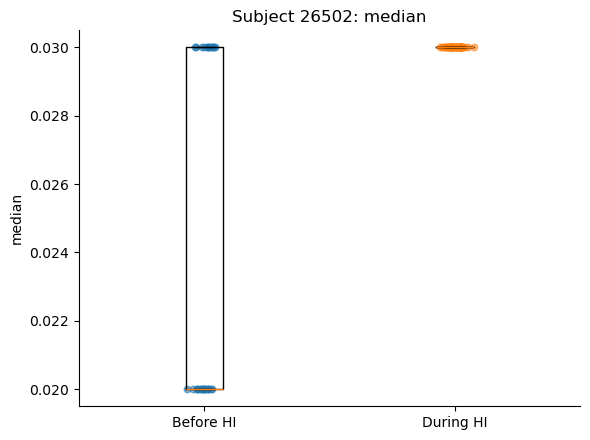

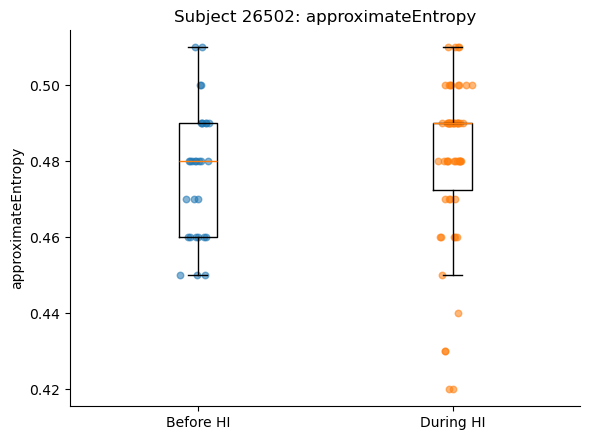

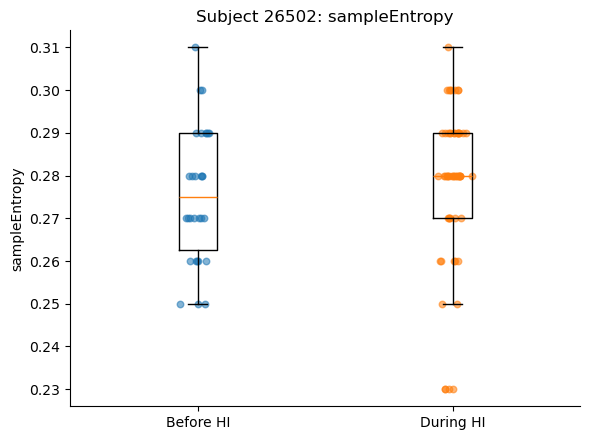

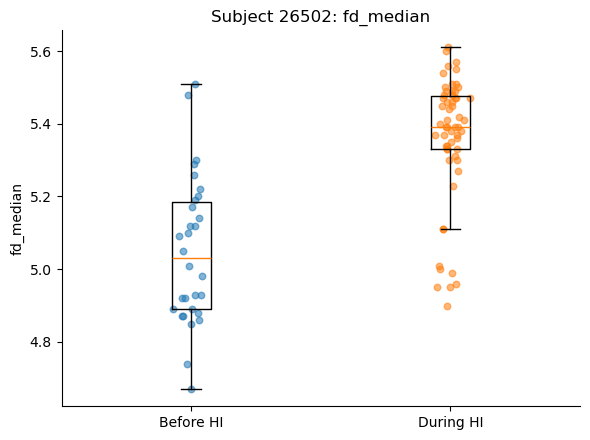

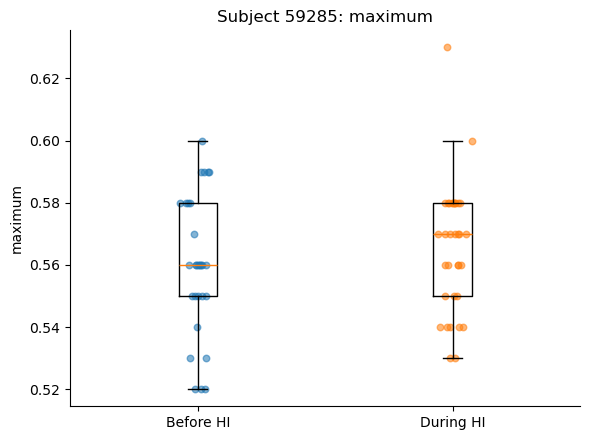

In [5]:


for subject_id, selected_features in audit_features.items():
    subject_data = audit_df.loc[
        audit_df[config.subject_col] == subject_id
    ]

    for feature in selected_features:
        before = subject_data.loc[
            subject_data[config.label_col] == config.before_label,
            feature,
        ].dropna()

        during = subject_data.loc[
            subject_data[config.label_col] == config.during_label,
            feature,
        ].dropna()

        fig, ax = plt.subplots(figsize=(6, 4.5))

        ax.boxplot(
            [before, during],
            tick_labels=["Before HI", "During HI"],
            showfliers=False,
        )

        rng = np.random.default_rng(42)

        ax.scatter(
            rng.normal(1, 0.035, len(before)),
            before,
            alpha=0.55,
            s=22,
            label="Before-HI windows",
        )

        ax.scatter(
            rng.normal(2, 0.035, len(during)),
            during,
            alpha=0.55,
            s=22,
            label="During-HI windows",
        )

        ax.set_ylabel(feature)
        ax.set_title(
            f"Subject {subject_id}: {feature}"
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        fig.tight_layout()

        output_path = (
            OUTPUT_DIR
            / f"audit_subject_{subject_id}_{feature}.png"
        )

        fig.savefig(
            output_path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()
        plt.close(fig)

# Stage 4: Identify extreme windows

Use a robust median absolute deviation rule within each patient and condition.

In [6]:
def robust_outlier_flags(values, threshold=3.5):
    values = pd.Series(values, dtype=float)

    median = values.median()
    mad = np.median(np.abs(values - median))

    if not np.isfinite(mad) or mad == 0:
        return pd.Series(False, index=values.index)

    modified_z = 0.6745 * (values - median) / mad

    return np.abs(modified_z) > threshold


outlier_rows = []

for subject_id, selected_features in audit_features.items():
    for feature in selected_features:
        for label, condition_name in [
            (config.before_label, "before_HI"),
            (config.during_label, "during_HI"),
        ]:
            mask = (
                (audit_df[config.subject_col] == subject_id)
                & (audit_df[config.label_col] == label)
            )

            values = audit_df.loc[mask, feature]
            flags = robust_outlier_flags(values)

            flagged_indices = flags.index[flags]

            for index in flagged_indices:
                outlier_rows.append(
                    {
                        "row_index": index,
                        "subject_id": subject_id,
                        "condition": condition_name,
                        "feature": feature,
                        "value": audit_df.loc[index, feature],
                    }
                )

audit_outliers = pd.DataFrame(outlier_rows)

display(audit_outliers)

audit_outliers.to_csv(
    OUTPUT_DIR / "audit_subject_outlier_windows.csv",
    index=False,
)

,row_index,subject_id,condition,feature,value
0,30,26502,during_HI,approximateEntropy,0.43
1,89,26502,during_HI,approximateEntropy,0.43
2,336,26502,during_HI,approximateEntropy,0.42
3,408,26502,during_HI,approximateEntropy,0.42
4,207,26502,during_HI,fd_median,4.95
5,336,26502,during_HI,fd_median,4.90
6,347,26502,during_HI,fd_median,4.96
7,408,26502,during_HI,fd_median,4.95
8,167,59285,during_HI,maximum,0.63


# Leave one Subject out Influence Analysis

In [7]:
influence_rows = []

for excluded_subject in sorted(
    audit_df[config.subject_col].unique()
):
    reduced_df = audit_df.loc[
        audit_df[config.subject_col] != excluded_subject
    ].copy()

    reduced_state = aggregate_subject_state(
        reduced_df,
        config,
        features,
    )

    reduced_results = paired_feature_analysis(
        reduced_state,
        config,
        features,
    )

    selected = reduced_results.loc[
        reduced_results["feature"].isin(
            [
                "maximum",
                "approximateEntropy",
                "sampleEntropy",
                "median",
                "fd_median",
            ]
        )
    ]

    for _, row in selected.iterrows():
        influence_rows.append(
            {
                "excluded_subject": excluded_subject,
                "feature": row["feature"],
                "median_difference": row["median_difference"],
                "direction_consistency": row[
                    "direction_consistency"
                ],
                "rank_biserial": row["rank_biserial"],
                "p_value": row["p_value"],
            }
        )

influence_results = pd.DataFrame(influence_rows)

display(influence_results)

influence_results.to_csv(
    OUTPUT_DIR / "leave_one_subject_out_effect_sensitivity.csv",
    index=False,
)

,excluded_subject,feature,median_difference,direction_consistency,rank_biserial,p_value
0,1855,sampleEntropy,-0.0475,0.7,-0.844444,0.023438
1,1855,maximum,-0.0125,0.7,-0.472727,0.201172
2,1855,fd_median,-0.1625,0.7,-0.418182,0.275391
3,1855,median,-0.0050,0.5,-0.785714,0.062500
4,1855,approximateEntropy,-0.0275,0.5,-0.666667,0.101562
5,26398,sampleEntropy,-0.0475,0.7,-0.844444,0.023438
6,26398,maximum,-0.0250,0.7,-0.545455,0.144531
7,26398,fd_median,-0.1625,0.7,-0.418182,0.275391
8,26398,median,-0.0050,0.5,-0.904762,0.062500
9,26398,approximateEntropy,-0.0275,0.5,-0.666667,0.101562


### Summary of leave-one-subject-out effect sensitivity

This analysis evaluated whether the observed paired feature changes were strongly dependent on any single subject. Each subject was removed in turn, and the patient-level paired statistics were recalculated using the remaining five subjects.

The analysis was not intended to estimate classification performance. Its purpose was to assess the stability of the observed feature effects.

#### Main findings

**Maximum amplitude was the most stable feature.**

* The median difference remained negative in every leave-one-subject-out analysis.
* Direction consistency remained high.
* The matched-pairs rank-biserial effect size stayed strongly negative.
* When subject `59285` was removed, all remaining subjects showed a decrease.

This indicates that the decrease in maximum amplitude is not driven by a single patient and is the most reproducible exploratory finding in the current cohort.

**Approximate entropy and sample entropy showed promising but patient-sensitive decreases.**

* Both features retained negative median differences across the reduced datasets.
* Their effects became stronger when subject `26502` was removed.
* This is consistent with the earlier finding that subject `26502` showed a small increase in both entropy measures while most other subjects showed decreases.

These entropy features remain plausible exploratory candidates, but their consistency is weaker than that of maximum amplitude.

Because approximate entropy and sample entropy are also highly correlated, the final compact feature set should likely retain only one of them.

**Median amplitude showed moderate stability.**

* Its median difference remained negative.
* Direction consistency improved when subjects `26398` or `26502` were removed.
* However, the effect was less consistent than maximum amplitude.

Median amplitude may be retained as a secondary exploratory feature but should be interpreted cautiously.

**Frequency-domain median was the least stable feature.**

* Its effect size varied substantially depending on which subject was removed.
* In some reduced datasets, the effect was weak or nearly absent.
* Removing subjects `26502` or `27245` strengthened the result because these subjects showed opposite-direction changes.

This suggests that frequency-domain median is highly influenced by individual patient responses and should not be prioritized as a stable candidate marker.

#### Statistical interpretation

None of the leave-one-subject-out paired analyses reached conventional statistical significance. This is expected because each reduced analysis contains only five subjects, giving the Wilcoxon signed-rank test very limited power.

The main value of this analysis is therefore not the p-value, but the stability of:

* effect direction;
* median difference;
* direction consistency;
* and matched-pairs effect size.

#### Overall interpretation

The leave-one-subject-out sensitivity analysis suggests the following ranking:

1. **Maximum amplitude** — most stable exploratory feature
2. **Approximate entropy** — promising but influenced by subject `26502`
3. **Sample entropy** — promising but redundant with approximate entropy
4. **Median amplitude** — moderately stable
5. **Frequency-domain median** — unstable and strongly subject-dependent

The results support retaining maximum amplitude as the strongest exploratory candidate and one entropy measure as a secondary nonlinear candidate. Frequency-domain median should be deprioritized.

These findings remain exploratory and require validation in a larger cohort.


# Plotting features per subject

In [13]:
from scipy.stats import gaussian_kde

def plot_subject_feature_raincloud(
    df: pd.DataFrame,
    subject_id,
    feature: str,
    config,
    output_dir: str | Path | None = None,
    show_plot: bool = True,
    random_seed: int = 42,
):
    """
    Plot before-HI and during-HI distributions for one feature in one subject.

    The raincloud plot contains:
    1. a half-violin density distribution;
    2. a boxplot;
    3. jittered individual 2-minute window values;
    4. median markers.

    Parameters
    ----------
    df
        Segment-level feature dataframe.

    subject_id
        Subject identifier to plot.

    feature
        Name of the feature column.

    config
        AnalysisConfig object containing:
        - subject_col
        - label_col
        - before_label
        - during_label

    output_dir
        Directory in which the figure should be saved.
        If None, the figure is not saved.

    show_plot
        Whether to display the figure.

    random_seed
        Seed used to make the point jitter reproducible.

    Returns
    -------
    fig, ax, summary
        Matplotlib figure, axis, and descriptive-statistics table.
    """

    # ------------------------------------------------------------
    # 1. Validate inputs
    # ------------------------------------------------------------
    if feature not in df.columns:
        raise ValueError(
            f"Feature '{feature}' was not found in the dataframe."
        )

    data = df.copy()
    data[config.subject_col] = (
        data[config.subject_col].astype(str)
    )

    subject_key = str(subject_id)

    available_subjects = set(
        data[config.subject_col].unique()
    )

    if subject_key not in available_subjects:
        raise ValueError(
            f"Subject '{subject_key}' was not found. "
            f"Available subjects: {sorted(available_subjects)}"
        )

    subject_data = data.loc[
        data[config.subject_col] == subject_key
    ].copy()

    before = (
        subject_data.loc[
            subject_data[config.label_col]
            == config.before_label,
            feature,
        ]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    during = (
        subject_data.loc[
            subject_data[config.label_col]
            == config.during_label,
            feature,
        ]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    if len(before) == 0:
        raise ValueError(
            f"No before-HI values found for subject {subject_key}."
        )

    if len(during) == 0:
        raise ValueError(
            f"No during-HI values found for subject {subject_key}."
        )

    groups = [before, during]
    positions = [1, 2]
    labels = ["Before HI", "During HI"]

    # ------------------------------------------------------------
    # 2. Create the figure
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))

    rng = np.random.default_rng(random_seed)

    all_values = np.concatenate(groups)

    value_min = np.nanmin(all_values)
    value_max = np.nanmax(all_values)

    value_range = value_max - value_min

    if value_range == 0:
        value_range = max(abs(value_max), 1.0) * 0.05

    y_grid = np.linspace(
        value_min - 0.05 * value_range,
        value_max + 0.05 * value_range,
        300,
    )

    # ------------------------------------------------------------
    # 3. Draw half-violin densities
    # ------------------------------------------------------------
    for position, values in zip(positions, groups):

        # KDE requires more than one unique observation.
        if len(values) > 1 and np.unique(values).size > 1:
            kde = gaussian_kde(values)
            density = kde(y_grid)

            # Scale density to a fixed visual width.
            if np.nanmax(density) > 0:
                density = (
                    density
                    / np.nanmax(density)
                    * 0.32
                )

            # Half violin placed to the left of the group position.
            ax.fill_betweenx(
                y_grid,
                position - density,
                position,
                alpha=0.35,
                linewidth=1,
            )

    # ------------------------------------------------------------
    # 4. Add narrow boxplots
    # ------------------------------------------------------------
    box = ax.boxplot(
        groups,
        positions=positions,
        widths=0.16,
        patch_artist=True,
        showfliers=False,
        medianprops={
            "linewidth": 2,
        },
        whiskerprops={
            "linewidth": 1,
        },
        capprops={
            "linewidth": 1,
        },
        boxprops={
            "linewidth": 1,
        },
    )

    for patch in box["boxes"]:
        patch.set_alpha(0.45)

    # ------------------------------------------------------------
    # 5. Add jittered individual observations
    # ------------------------------------------------------------
    for position, values, label in zip(
        positions,
        groups,
        labels,
    ):
        jitter = rng.normal(
            loc=position + 0.20,
            scale=0.025,
            size=len(values),
        )

        ax.scatter(
            jitter,
            values,
            alpha=0.55,
            s=24,
            edgecolors="none",
            label=f"{label} windows",
        )

    # ------------------------------------------------------------
    # 6. Add median markers
    # ------------------------------------------------------------
    medians = [
        np.median(before),
        np.median(during),
    ]

    ax.scatter(
        positions,
        medians,
        marker="D",
        s=45,
        zorder=5,
        label="Median",
    )

    # Connect condition medians.
    ax.plot(
        positions,
        medians,
        linestyle="--",
        linewidth=1.2,
        alpha=0.8,
    )

    # ------------------------------------------------------------
    # 7. Format the plot
    # ------------------------------------------------------------
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)

    ax.set_ylabel(feature)
    ax.set_xlabel("Hemodynamic condition")

    ax.set_title(
        f"Subject {subject_key}: {feature}\n"
        "Window-level before-HI and during-HI distributions"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.20,
    )

    ax.legend(
        frameon=False,
        fontsize=8,
        loc="best",
    )

    fig.tight_layout()

    # ------------------------------------------------------------
    # 8. Calculate descriptive statistics
    # ------------------------------------------------------------
    summary = pd.DataFrame(
        {
            "subject_id": [subject_key, subject_key],
            "feature": [feature, feature],
            "condition": ["before_HI", "during_HI"],
            "n_windows": [len(before), len(during)],
            "mean": [
                np.mean(before),
                np.mean(during),
            ],
            "median": [
                np.median(before),
                np.median(during),
            ],
            "standard_deviation": [
                np.std(before, ddof=1),
                np.std(during, ddof=1),
            ],
            "q1": [
                np.quantile(before, 0.25),
                np.quantile(during, 0.25),
            ],
            "q3": [
                np.quantile(before, 0.75),
                np.quantile(during, 0.75),
            ],
            "minimum": [
                np.min(before),
                np.min(during),
            ],
            "maximum": [
                np.max(before),
                np.max(during),
            ],
        }
    )

    # ------------------------------------------------------------
    # 9. Save the figure and statistics
    # ------------------------------------------------------------
    if output_dir is not None:
        output_dir = Path(output_dir)
        output_dir.mkdir(
            parents=True,
            exist_ok=True,
        )

        safe_feature = (
            feature.replace("/", "_")
            .replace(" ", "_")
        )

        figure_path = (
            output_dir
            / f"raincloud_subject_{subject_key}_{safe_feature}.png"
        )

        summary_path = (
            output_dir
            / f"raincloud_subject_{subject_key}_{safe_feature}_summary.csv"
        )

        fig.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight",
        )

        summary.to_csv(
            summary_path,
            index=False,
        )

        print("Saved figure:", figure_path)
        print("Saved summary:", summary_path)

    if show_plot:
        plt.show()
    else:
        plt.close(fig)

    return fig, ax, summary

In [9]:
# Print available subject IDs
subjects = sorted(
    df[config.subject_col]
    .astype(str)
    .unique()
)

print("Available subjects:")
for subject_id in subjects:
    print(subject_id)


# Print available feature names
feature_names = [
    column
    for column in df.columns
    if column not in {
        config.subject_col,
        config.label_col,
    }
]

print("\nAvailable features:")
for feature in feature_names:
    print(feature)

Available subjects:
1855
26398
26502
27245
30071
30851
57091
59285
638
70447
8452

Available features:
maximum
minimum
mean
median
standardDeviation
variance
kurtosis
skewness
numberOfZeroCrossing
positiveToNegativeSampleRatio
meanAbsoluteValue
approximateEntropy
sampleEntropy
permutationEntropy
singularValueDecompositionEntropy
shannonEntropy
renyiEntropy
lempelZivComplexity
hjorthMobility
hjorthComplexity
fisherInfo
petrosianFd
katzFd
higuchiFd
detrendedFluctuation
fd_maximum
fd_minimum
fd_mean
fd_median
fd_standardDeviation
fd_variance
fd_kurtosis
fd_skewness
spectralEntropy
fd_bandPower


Saved figure: analysis_outputs/raincloud_subject_26502_sampleEntropy.png
Saved summary: analysis_outputs/raincloud_subject_26502_sampleEntropy_summary.csv


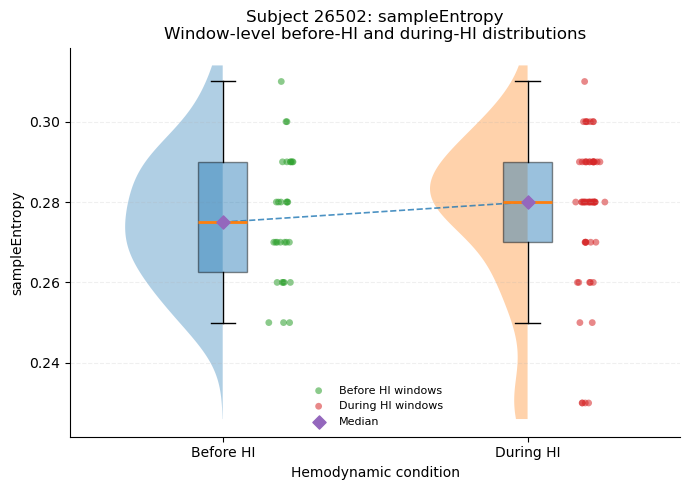

,subject_id,feature,condition,n_windows,mean,median,standard_deviation,q1,q3,minimum,maximum
0,26502,sampleEntropy,before_HI,30,0.275667,0.275,0.015687,0.2625,0.29,0.25,0.31
1,26502,sampleEntropy,during_HI,58,0.278103,0.280,0.018397,0.2700,0.29,0.23,0.31


In [22]:
fig, ax, summary = plot_subject_feature_raincloud(
    df=audit_df,
    subject_id="26502",
    feature="sampleEntropy",
    config=config,
    output_dir=OUTPUT_DIR,
)

display(summary)

Saved figure: analysis_outputs/raincloud_subject_26502_median.png
Saved summary: analysis_outputs/raincloud_subject_26502_median_summary.csv


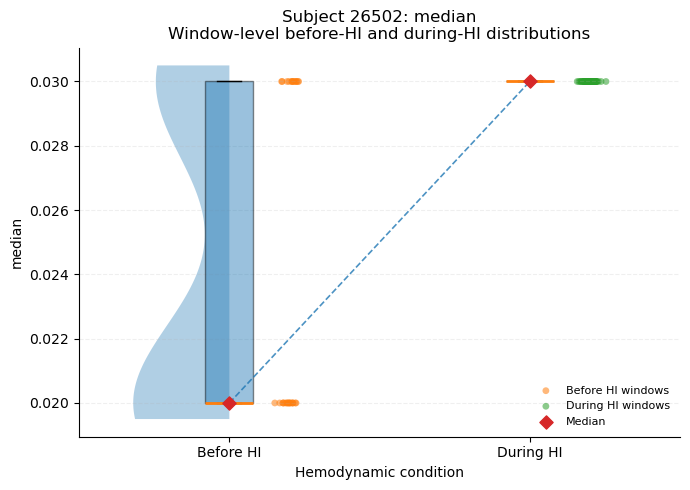

,subject_id,feature,condition,n_windows,mean,median,standard_deviation,q1,q3,minimum,maximum
0,26502,median,before_HI,30,0.024333,0.02,0.00504,0.02,0.03,0.02,0.03
1,26502,median,during_HI,58,0.030000,0.03,0.00000,0.03,0.03,0.03,0.03


Saved figure: analysis_outputs/raincloud_subject_26502_sampleEntropy.png
Saved summary: analysis_outputs/raincloud_subject_26502_sampleEntropy_summary.csv


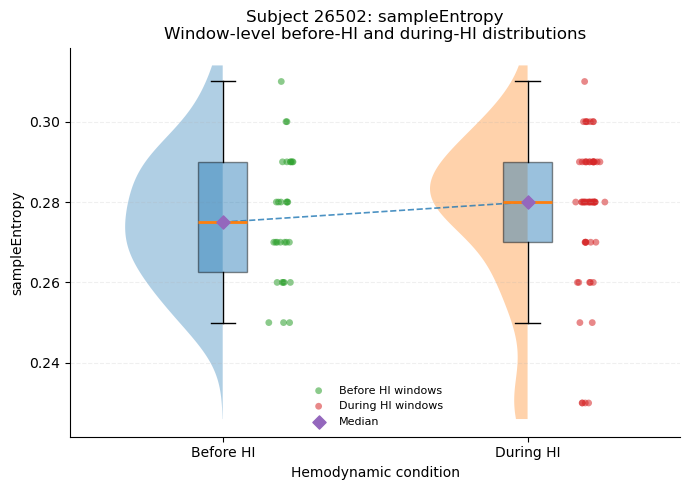

,subject_id,feature,condition,n_windows,mean,median,standard_deviation,q1,q3,minimum,maximum
0,26502,sampleEntropy,before_HI,30,0.275667,0.275,0.015687,0.2625,0.29,0.25,0.31
1,26502,sampleEntropy,during_HI,58,0.278103,0.280,0.018397,0.2700,0.29,0.23,0.31


Saved figure: analysis_outputs/raincloud_subject_26502_skewness.png
Saved summary: analysis_outputs/raincloud_subject_26502_skewness_summary.csv


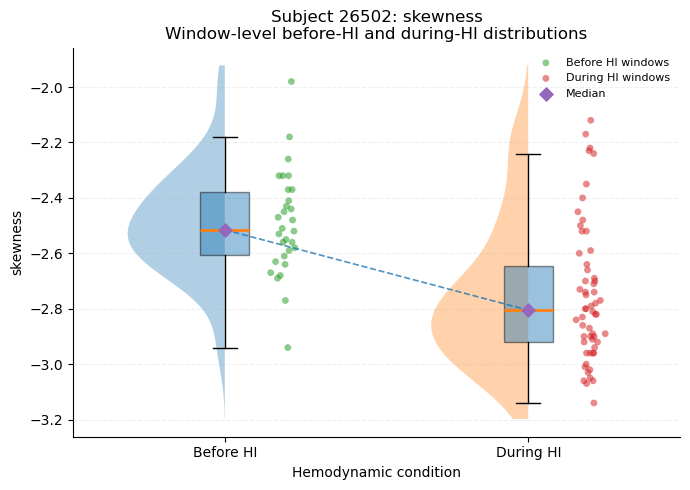

,subject_id,feature,condition,n_windows,mean,median,standard_deviation,q1,q3,minimum,maximum
0,26502,skewness,before_HI,30,-2.494333,-2.515,0.187445,-2.605,-2.380,-2.94,-1.98
1,26502,skewness,during_HI,58,-2.753276,-2.805,0.248500,-2.920,-2.645,-3.14,-2.12


In [23]:
subject_id = "26502"

features_to_plot = [
    "median",
    "sampleEntropy",
    "skewness",
]

for feature in features_to_plot:
    fig, ax, summary = plot_subject_feature_raincloud(
        df=audit_df,
        subject_id=subject_id,
        feature=feature,
        config=config,
        output_dir=OUTPUT_DIR,
    )

    display(summary)